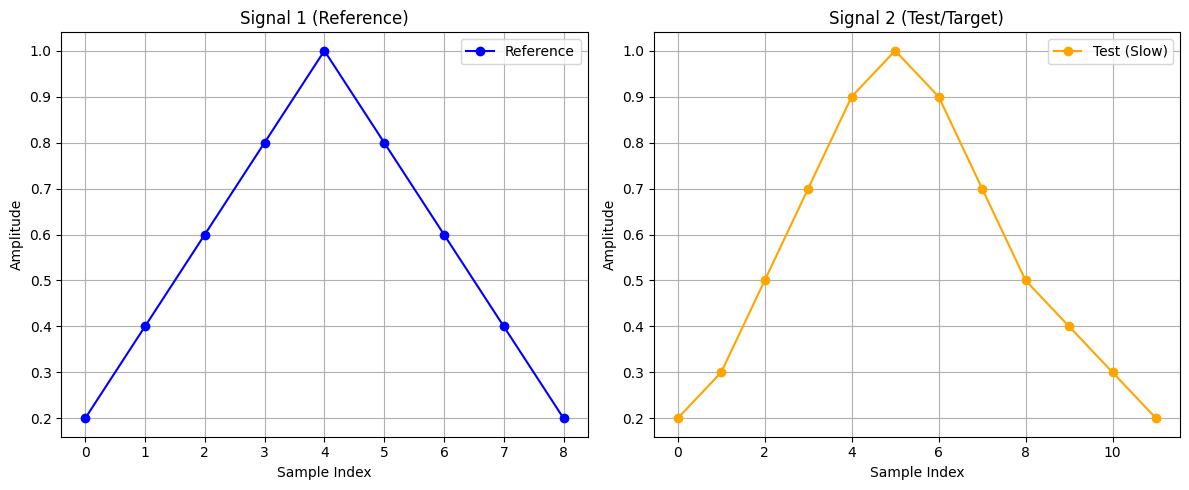

Original Signal 2 Length: 12
Normalized Signal 2 Length: 9
Normalized Data: [0.2  0.38 0.65 0.91 0.95 0.72 0.48 0.34 0.2 ]

Mean Squared Error (MSE) after alignment: 0.0048


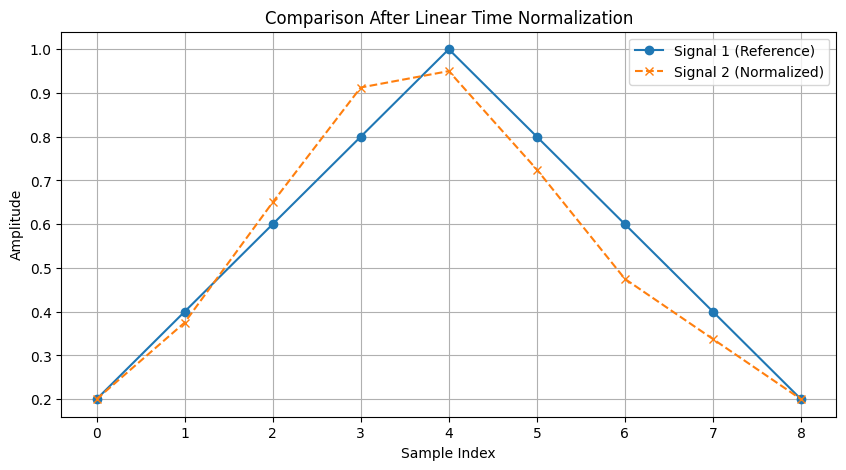

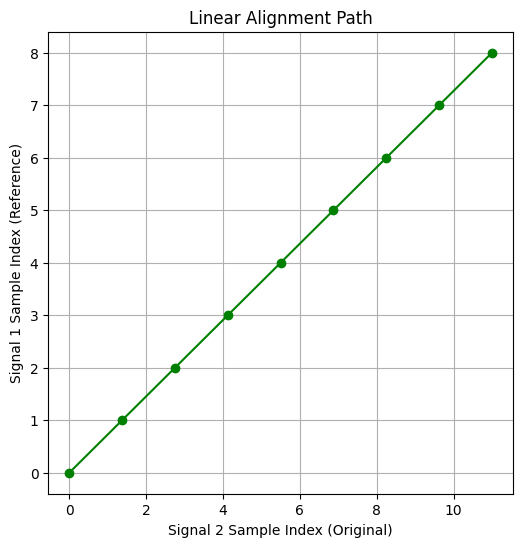

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ==========================================
# 1. Define the Given Data
# ==========================================
# Signal 1 (Reference) - Normal speed
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])

# Signal 2 (Test) - Slower speed (more samples)
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])

# ==========================================
# 2. Task: Plot differences in length/amplitude
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Signal 1
plt.subplot(1, 2, 1)
plt.plot(signal1, marker='o', color='blue', label='Reference')
plt.title('Signal 1 (Reference)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot Signal 2
plt.subplot(1, 2, 2)
plt.plot(signal2, marker='o', color='orange', label='Test (Slow)')
plt.title('Signal 2 (Test/Target)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. Task: Perform Linear Time Normalization
# ==========================================
# We need to compress Signal 2 to match the length of Signal 1.
len1 = len(signal1)
len2 = len(signal2)

# Create the original time axis for Signal 2 (normalized 0 to 1)
x_original = np.linspace(0, 1, len2)

# Create the interpolation function based on Signal 2
interpolator = interp1d(x_original, signal2, kind='linear')

# Create the new time axis matching Signal 1's length (normalized 0 to 1)
x_new = np.linspace(0, 1, len1)

# Generate the normalized Signal 2
signal2_normalized = interpolator(x_new)

print("Original Signal 2 Length:", len(signal2))
print("Normalized Signal 2 Length:", len(signal2_normalized))
print("Normalized Data:", np.round(signal2_normalized, 2))

# ==========================================
# 4. Task: Compute Alignment (MSE)
# ==========================================
alignment_diff = signal1 - signal2_normalized
mse = np.mean(alignment_diff ** 2)

print(f"\nMean Squared Error (MSE) after alignment: {mse:.4f}")

# Visualization of Aligned Signals
plt.figure(figsize=(10, 5))
plt.plot(signal1, 'o-', label='Signal 1 (Reference)')
plt.plot(signal2_normalized, 'x--', label='Signal 2 (Normalized)')
plt.title('Comparison After Linear Time Normalization')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 5. Task: Plot the Alignment Path
# ==========================================
# This visualizes how indices in the longer signal map to the reference signal
ref_indices = np.arange(len1)
mapped_indices = np.linspace(0, len2 - 1, len1)

plt.figure(figsize=(6, 6))
plt.plot(mapped_indices, ref_indices, marker='o', color='green')
plt.title('Linear Alignment Path')
plt.xlabel('Signal 2 Sample Index (Original)')
plt.ylabel('Signal 1 Sample Index (Reference)')
plt.grid(True)
plt.show()